
Before COVID
assets: 	 ['AAPL', 'TSLA', 'AMZN']
exp ret: 	 [25.55 25.41 26.08]
std: 		 [25.86 50.05 28.19]
skew: 		 [-0.38 -0.06  0.18]
kurt: 		 [8.42 9.19 8.95]

After COVID
assets: 	 ['AAPL', 'TSLA', 'AMZN']
exp ret: 	 [26.09 42.97 17.49]
std: 		 [30.76 64.65 35.48]
skew: 		 [ 0.13 -0.05 -0.06]
kurt: 		 [9.58 6.21 7.43]


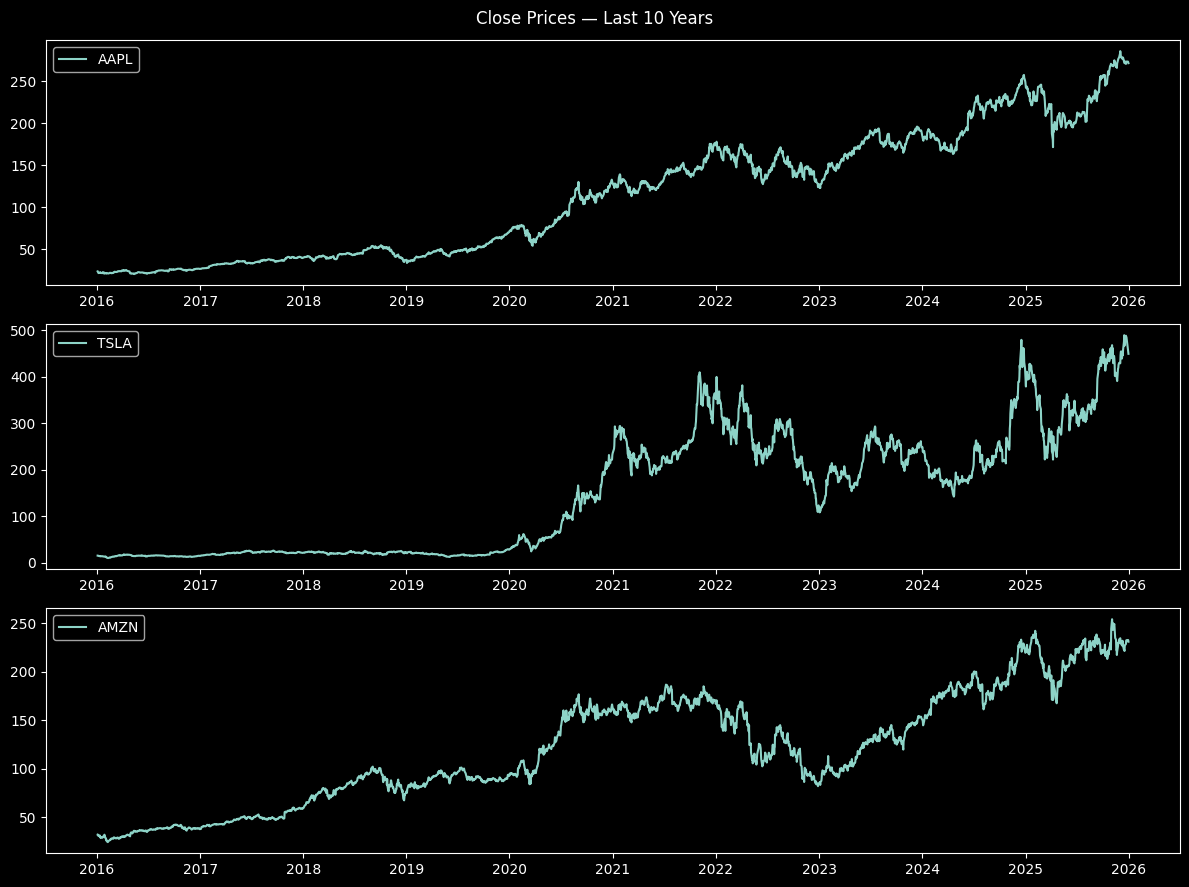

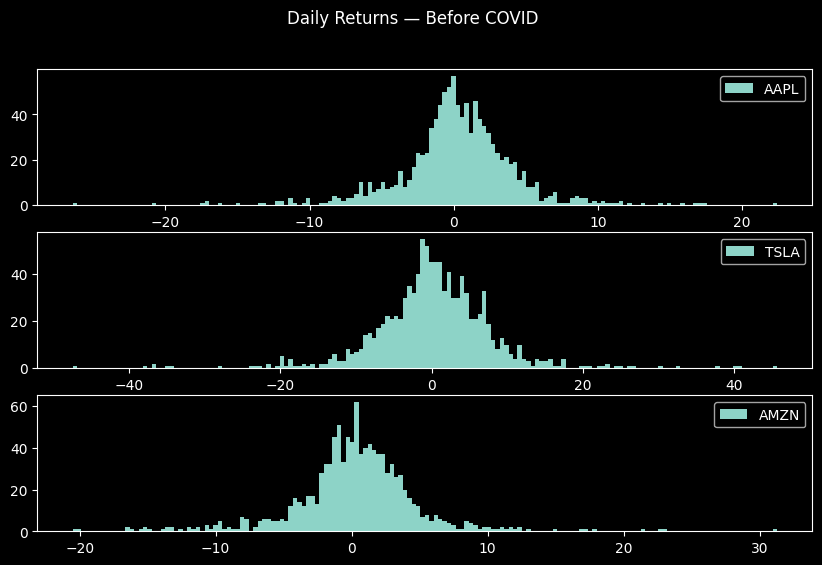

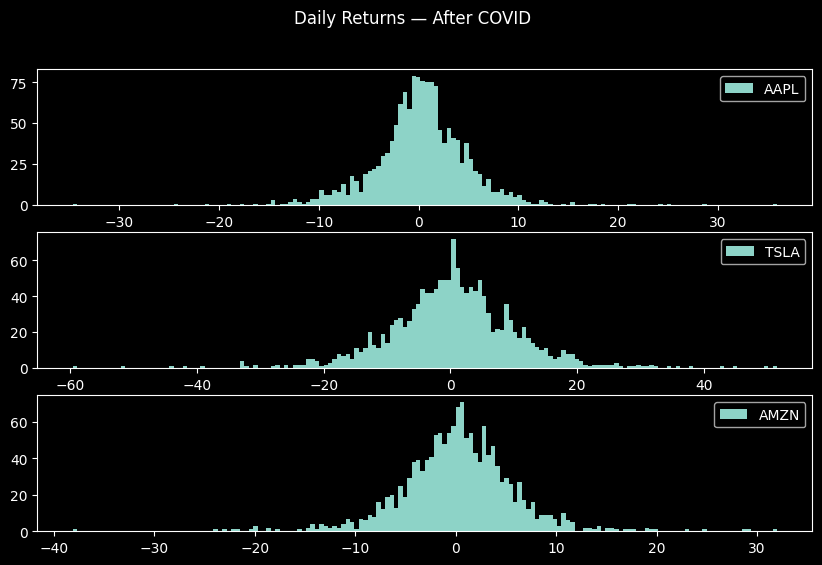

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt                                                           #Draws all the charts and graphs
import numpy as np                                                                        #Does fast math on lists of numbers
import math
from scipy.stats import skew, kurtosis

v_assets = ['AAPL', 'TSLA', 'AMZN']
periods = {
    'Before COVID': ('2016-01-01', '2020-03-11'),
    'After COVID':  ('2020-03-12', '2026-01-01')
}

plt.figure(figsize = (12, 9))
plt.style.use('dark_background')
plt.suptitle('Close Prices Last 10 Years')
for i, ticker in enumerate(v_assets):
    prices = yf.Ticker(ticker).history(start = '2016-01-01', end = '2026-01-01') ['Close']
    plt.subplot(3, 1, i + 1)
    plt.plot(prices, label = ticker)
    plt.legend(loc = 2)
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.tight_layout()                                                                        #Automatically adjusts spacing between subplots

for period, (start, end) in periods.items():
    m_close = [yf.Ticker(t).history(start = start, end = end) ['Close'] for t in v_assets]

    min_len = min(len(p) for p in m_close) - 1
    m_log_ret = np.array([[np.log(m_close[j].iloc[i + 1] / m_close[j].iloc[i])
                           for j in range(len(v_assets))] for i in range(min_len)])

    plt.figure(figsize = (10, 6))
    plt.style.use('dark_background')
    plt.suptitle(f'Daily Returns {period}')
    for i in range(len(v_assets)):
        plt.subplot(3, 1, i + 1)
        plt.hist(m_log_ret[:, i]*252, label = v_assets[i], bins = 160)                         #[:,i]=[all the returns,i]
        plt.legend(loc = 1)

    print(f'\n{period}')
    print('assets: \t', v_assets)
    print('exp ret: \t', np.round(100 * np.mean(m_log_ret, axis = 0) * 252, 2))           #Average yearly profit in percent
    print('std: \t\t', np.round(100 * np.std(m_log_ret, axis = 0) * math.sqrt(252), 2))   #Risk (how much the stock price jumps around)
    print('skew: \t\t', np.round(skew(m_log_ret), 2))                                     #Big losses or big gains are more extreme
    print('kurt: \t\t', np.round(kurtosis(m_log_ret) + 3, 2))                             #How often extreme days happen(a perfectly normal distribution = 3)